<h1>Chapter 7-Homework-Problem 3</h1>

<p>In this exercise, we will use discriminant analysis to classify borrowers as either likely to default or unlikely to default on a loan. A bank wants to evaluate loan applications in order to reduce the risk of default. Each observation in the dataset represents one borrower.</p>

<p>The dependent variable (group) is the borrower’s default:<br />
•	1 = Default (high risk)<br />
•	0 = No default (low risk)</p>

<p>Some explanatory variables include:<br />
•	duration – loan duration (in months)<br />
•	amount – loan amount<br />
•	age – borrower’s age<br />
•	installment_rate – percentage of income used for loan payments<br />
•	number_credits – number of existing loans</p>

<p>a. Compute summary statistics for the explanatory variables. Compare borrowers who default with those who do not.</p>

<p>b. Select one key variable and visualize its distribution using a histogram. Compare the distributions across the two groups.</p>

<p>c. Estimate a discriminant model using Linear Discriminant Analysis (LDA).<br />
•	Split the data into training (80%) and testing (20%) sets<br />
•	Use the model to classify borrowers<br />
•	Construct and interpret a confusion matrix</p>



Summary statistics by credit risk:
              duration       amount        age  installment_rate  \
credit_risk                                                        
0            24.860000  3938.126667  33.963333          3.096667   
1            19.207143  2985.457143  36.224286          2.920000   

             number_credits  
credit_risk                  
0                  1.366667  
1                  1.424286  


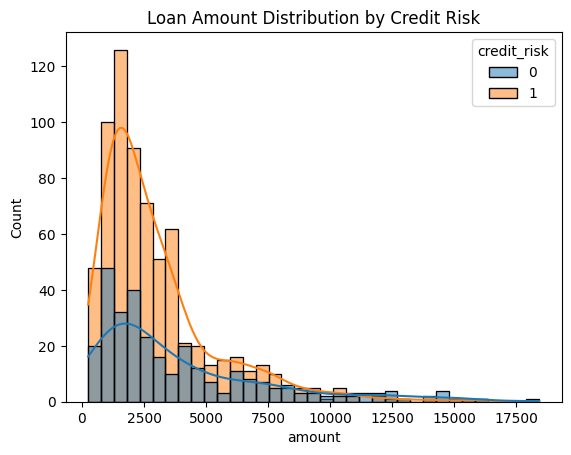


Accuracy: 0.70

Confusion Matrix:
[[  7  53]
 [  6 134]]


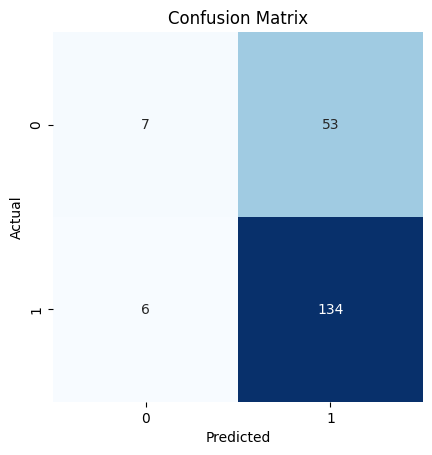

In [2]:
# ============================================
# Discriminant Analysis: Loan Default Example
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

# --------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------
df = pd.read_csv('Chapter_07-GermanCredit.csv')

# --------------------------------------------
# Step 3: Data preparation
# --------------------------------------------
# Select relevant variables
df_model = df[[
    'duration',
    'amount',
    'age',
    'installment_rate',
    'number_credits',
    'credit_risk'
]].copy()

# Drop missing values
df_model = df_model.dropna()

# Define features (X) and target (y)
X = df_model[['duration', 'amount', 'age', 'installment_rate', 'number_credits']]
y = df_model['credit_risk']

# --------------------------------------------
# Step 4: Exploratory analysis
# --------------------------------------------
print("\nSummary statistics by credit risk:")
print(df_model.groupby('credit_risk').mean())

# Visualize distribution
plt.figure()
sns.histplot(data=df_model, x='amount', hue='credit_risk', kde=True)
plt.title("Loan Amount Distribution by Credit Risk")
plt.show()

# --------------------------------------------
# Step 5: Split into training and testing sets
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures balanced classes in both sets
)

# --------------------------------------------
# Step 6: Apply Linear Discriminant Analysis (LDA)
# --------------------------------------------
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

# Predict on test data
y_pred = lda.predict(X_test)

# --------------------------------------------
# Step 7: Evaluate model performance
# --------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")

print("\nConfusion Matrix:")
print(conf_matrix)

# --------------------------------------------
# Step 8: Visualize confusion matrix
# --------------------------------------------
plt.figure()
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    square=True,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
